In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Read the data file

In [3]:
def read_data(file_path):
    """
    Read tab-delimited data file
    """
    df = pd.read_csv(file_path, sep='\t', header=None)
    return df

file_path = 'mapped.bed'
df = read_data(file_path)
print(f"Data loaded: {df.shape[0]} rows and {df.shape[1]} columns")
print("\nFirst few rows of the data:")
display(df.head())

Data loaded: 1016651 rows and 13 columns

First few rows of the data:


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90838.0,91006.0,IH02_00.pairs@15152,168.0,+
1,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90846.0,90998.0,IH02_04.pairs@4163,152.0,+
2,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90851.0,91000.0,IH02_04.pairs@4164,149.0,+
3,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90850.0,91014.0,IH02_00.pairs@15153,164.0,+
4,2,chr1,90919,91937,chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGG...,16.2951,+,chr1,90900.0,90965.0,IH02_00.pairs@15164,65.0,+


### Step 2: Calculate X, Y, Z values according to the problem statement
    Calculate X, Y, Z values for V-plot:
    X: Difference between centers (C2 - C1)
    Y: Fragment size (Column10 - Column9)
    Z: Counter of Y at X (frequency of each Y value at each X position)

In [5]:
def calculate_xyz(df):

    # Calculate center positions
    df['C1'] = (df[2] + df[3]) / 2  # Center using Column3 and Column4
    df['C2'] = (df[8] + df[9]) / 2  # Center using Column9 and Column10

    # Calculate X: difference between centers
    df['X'] = df['C2'] - df['C1']
    df['X'] = df['X'].round()
    df['X'] = df['X'].fillna(0).astype(int)

    # Calculate Y: fragment size
    df['Y'] = df[9] - df[8]

    xy_counts = df.groupby(['X', 'Y']).size().reset_index(name='Z')

    return xy_counts

xyz_data = calculate_xyz(df)

print("\nSample of calculated X, Y, Z values:")
display(xyz_data.head())


Calculating X, Y, Z values...

Sample of calculated X, Y, Z values:


,X,Y,Z
0,-509,44.0,2
1,-509,46.0,1
2,-509,48.0,2
3,-509,50.0,5
4,-509,52.0,7


### Step 3: Create a V-plot heatmap
    Create a V-plot heatmap showing fragment size vs position relative to binding site
    
    Parameters:
    - xyz_data: DataFrame with X, Y, Z columns
    - output_file: If provided, save the plot to this file


Generating V-plot...
Plot saved to v_plot.png


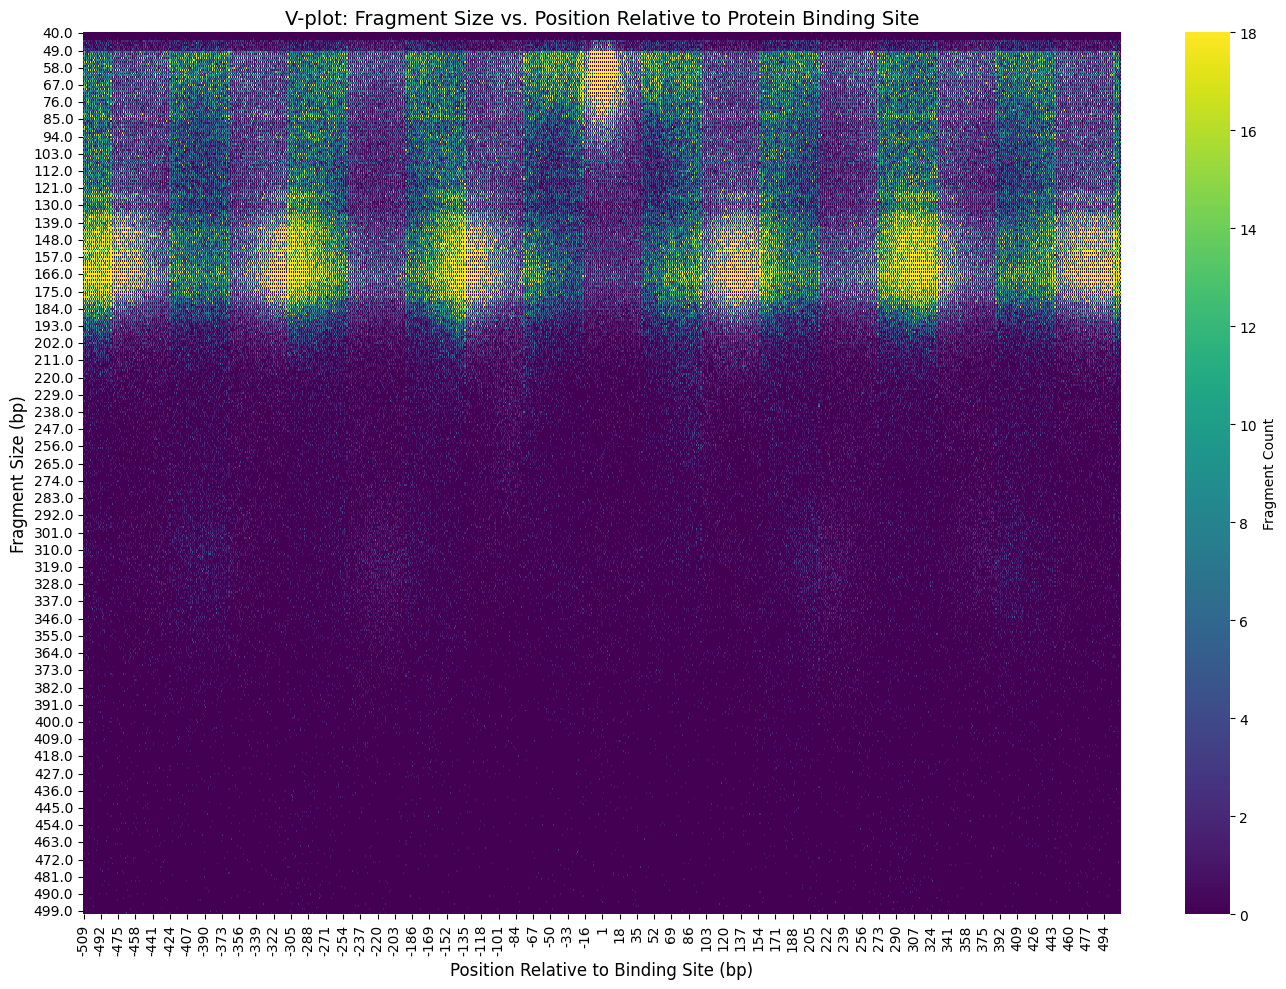

In [6]:
def create_vplot(xyz_data, output_file=None):

    # Convert to a pivot table format suitable for heatmap
    pivot_data = xyz_data.pivot_table(values='Z', index='Y', columns='X', fill_value=0)

    plt.figure(figsize=(14, 10))

    sns.heatmap(pivot_data, cmap='viridis', robust=True)


    plt.xlabel('Position Relative to Binding Site (bp)', fontsize=12)
    plt.ylabel('Fragment Size (bp)', fontsize=12)
    plt.title('V-plot: Fragment Size vs. Position Relative to Protein Binding Site', fontsize=14)


    cbar = plt.gca().collections[0].colorbar
    cbar.set_label('Fragment Count', fontsize=10)

    plt.tight_layout()

    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {output_file}")

    return plt

# Create the V-plot
print("\nGenerating V-plot...")
vplot = create_vplot(xyz_data, output_file='v_plot.png')
plt.show()